## Modéle de classification des frauds des transactions bancaires en utilisant la regression logistique

le travail est fait par EL QARNIA SAMAH (toute seule)

In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import warnings
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")

In [3]:
df=pd.read_csv('AIML Dataset.csv')
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [4]:
df["isFraud"].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [5]:
df.shape

(6362620, 11)

extraction de 100000 lignes du dataset original puisque sa taille est trop grande

In [61]:
import random

k = 100000
reservoir = []
with open("AIML Dataset.csv", "r") as f:
    header = f.readline()
    for i, line in enumerate(f, 1):
        if i <= k:
            reservoir.append(line)
        else:
            j = random.randint(1, i)
            if j <= k:
                reservoir[j-1] = line

with open("extrait_dataset.csv", "w") as out:
    out.write(header)
    out.writelines(reservoir)


In [6]:
dataset=pd.read_csv("extrait_dataset.csv")

In [7]:
dataset.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,352,CASH_OUT,156131.68,C2085681612,493.00,0.00,C855851095,0.00,156131.68,0,0
1,403,CASH_OUT,244950.68,C1953718837,3819.00,0.00,C817778646,232055.49,477006.17,0,0
2,283,PAYMENT,8598.29,C2097622979,141928.72,133330.42,M1140618685,0.00,0.00,0,0
3,322,CASH_OUT,389438.33,C94719147,0.00,0.00,C1987494745,682741.21,1248554.96,0,0
4,202,PAYMENT,300.93,C980712201,0.00,0.00,M1898714663,0.00,0.00,0,0


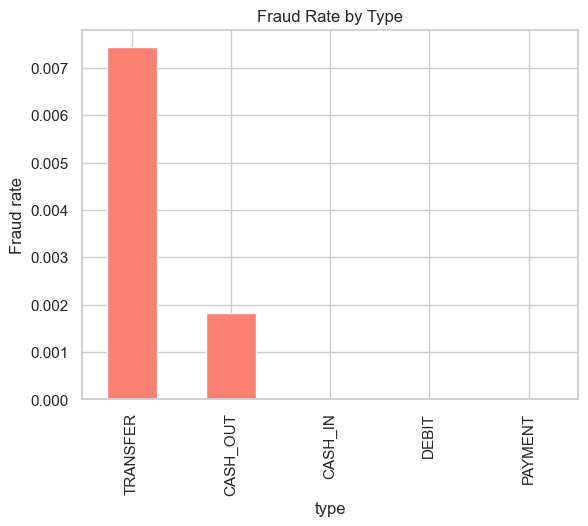

In [8]:
#some analysis before training our data
fraud_by_type=dataset.groupby("type")["isFraud"].mean().sort_values(ascending=False)
fraud_by_type.plot(kind="bar",title='Fraud Rate by Type',color="salmon")
plt.ylabel('Fraud rate')
plt.show()

## preparation des données

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

on constate que la majorite est non fraud et le fraud represente presque 1% des données

In [10]:
dataset["isFraud"].value_counts()

isFraud
0    99874
1      126
Name: count, dtype: int64

In [11]:
df_model=dataset.drop(['nameOrig','nameDest','isFlaggedFraud'],axis=1)

In [12]:
categorical=['type']
numeric=['amount','oldbalanceOrg','newbalanceOrig','oldbalanceDest','newbalanceDest']

In [13]:
y=df_model['isFraud']
X=df_model.drop('isFraud',axis=1)

In [14]:

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3,  stratify=y)

In [15]:
preprocessor=ColumnTransformer(
    transformers=[
        ("num",StandardScaler(),numeric),
        ("cat",OneHotEncoder(drop="first"),categorical)
    ],
    remainder="drop"
)

In [16]:
# --- Apply preprocessing ---
X_train_pre = preprocessor.fit_transform(X_train)
X_test_pre  = preprocessor.transform(X_test)

print("Train shape:", X_train_pre.shape)
print("Test shape:",  X_test_pre.shape)




Train shape: (70000, 9)
Test shape: (30000, 9)


In [17]:
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train_pre, y_train)

## Classification des transactions selon le modéle de la Regression logistique  from scratch

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Sigmoid ---
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# --- Initialize weights ---
def initialisation(X):
    W = np.zeros((X.shape[1],1))
    b = 0.0
    return W, b

# --- Forward model ---
def modele(X, W, b):
    Z = X.dot(W) + b
    return sigmoid(Z)

# --- Log loss ---
def log_loss(y, A):
    eps = 1e-9
    A = np.clip(A, eps, 1-eps)
    return -np.mean(y*np.log(A) + (1-y)*np.log(1-A))


# --- Gradients with class weighting ---
def gradients(X, A, y):
    m = len(y)
    dW = 1/m * X.T.dot(A - y)
    db = 1/m * np.sum(A - y)
    return dW, db

def train_logistic(X, y, lr=0.001, n_iter=8000):
    y = y.values.reshape(-1,1)
    W, b = initialisation(X)
    losses = []

    for i in range(n_iter):
        A = modele(X, W, b)
        loss = log_loss(y, A)
        losses.append(loss)

        dW, db = gradients(X, A, y)
        W -= lr*dW
        b -= lr*db

        if i % 1000 == 0:
            print(f"Iter {i}, Loss={loss:.5f}")

    plt.plot(losses)
    plt.title("Log-loss")
    plt.xlabel("Iterations")
    plt.ylabel("Loss")
    plt.show()

    return W, b

Iter 0, Loss=0.69315
Iter 1000, Loss=0.47840
Iter 2000, Loss=0.43955
Iter 3000, Loss=0.41948
Iter 4000, Loss=0.40663
Iter 5000, Loss=0.39737
Iter 6000, Loss=0.39015
Iter 7000, Loss=0.38425
Iter 8000, Loss=0.37923
Iter 9000, Loss=0.37486
Iter 10000, Loss=0.37098
Iter 11000, Loss=0.36747
Iter 12000, Loss=0.36425
Iter 13000, Loss=0.36129
Iter 14000, Loss=0.35851
Iter 15000, Loss=0.35592
Iter 16000, Loss=0.35346
Iter 17000, Loss=0.35113
Iter 18000, Loss=0.34890
Iter 19000, Loss=0.34677
Iter 20000, Loss=0.34474
Iter 21000, Loss=0.34279
Iter 22000, Loss=0.34092
Iter 23000, Loss=0.33911
Iter 24000, Loss=0.33737
Iter 25000, Loss=0.33570
Iter 26000, Loss=0.33408
Iter 27000, Loss=0.33251
Iter 28000, Loss=0.33099
Iter 29000, Loss=0.32952
Iter 30000, Loss=0.32809
Iter 31000, Loss=0.32671
Iter 32000, Loss=0.32536
Iter 33000, Loss=0.32405
Iter 34000, Loss=0.32278
Iter 35000, Loss=0.32154
Iter 36000, Loss=0.32034
Iter 37000, Loss=0.31916
Iter 38000, Loss=0.31802
Iter 39000, Loss=0.31690
Iter 40000, L

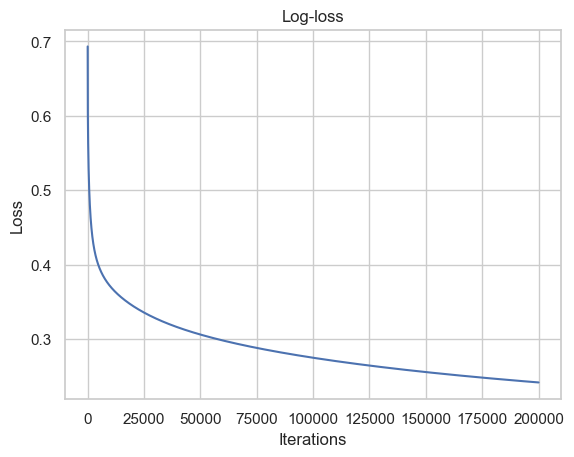

In [24]:
W, b = train_logistic(X_res, y_res, lr=0.01, n_iter=200000)

In [33]:
y_pred_prob = modele(X_test_pre, W, b).ravel()
y_pred = (y_pred_prob >= 0.5).astype(int)
from sklearn.metrics import accuracy_score,recall_score,confusion_matrix
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("confusion matrix:",confusion_matrix(y_test,y_pred))


Accuracy : 0.9218
Recall: 0.7894736842105263
confusion matrix: [[27624  2338]
 [    8    30]]


In [ ]:
np.save("W1.npy", W) 
np.save("b1.npy", b) 